In [2]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

words = open('../names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stringToIntegerMap = {s:i+1 for i,s in enumerate(chars)}
stringToIntegerMap['.'] = 0
integerToStrigMapping = {s:i for i,s in stringToIntegerMap.items()}
integerToStrigMapping

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [7]:
#create the training set of bigram

xs, ys = [], []

for w in words[:1]:
    wordWithStops = ['.']+list(w)+['.']
    for ch1, ch2 in zip(wordWithStops,wordWithStops[1:]):
        idCh1 = stringToIntegerMap[ch1]
        idCh2 = stringToIntegerMap[ch2]
        print(ch1, ch2)
        xs.append(idCh1)
        ys.append(idCh2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)


. e
e m
m m
m a
a .


tensor([ 0,  5, 13, 13,  1])

In [8]:
xs

tensor([ 0,  5, 13, 13,  1])

In [9]:
ys

tensor([ 5, 13, 13,  1,  0])

In [10]:
import torch.nn.functional as F
xEncoded = F.one_hot(xs, num_classes=27).float()
xEncoded

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

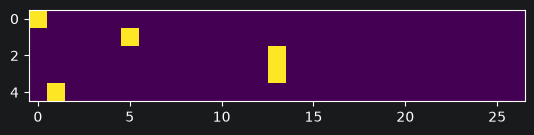

In [11]:
plt.imshow(xEncoded)

In [12]:
xEncoded.size()

torch.Size([5, 27])

In [22]:
W = torch.randn((27,27))
W

tensor([[-9.7343e-01, -1.1059e+00, -1.0109e+00, -6.5439e-01,  1.3471e+00,
         -1.7919e+00,  1.2841e+00,  6.6975e-01, -9.9307e-01, -5.4407e-01,
         -7.7134e-01,  1.2499e+00,  5.3592e-01,  7.6240e-01, -6.8795e-01,
         -2.0813e+00, -1.4618e+00,  5.9389e-01,  7.3463e-01,  5.3309e-01,
          4.2072e-01, -8.8643e-01, -3.2192e-01, -9.6049e-01, -1.5894e-03,
          8.9940e-01,  1.0633e+00],
        [ 7.9393e-01, -9.4040e-02, -5.0624e-01, -3.9901e-01, -2.7782e-02,
          6.0331e-02, -1.9593e+00,  1.1620e-01, -1.7266e+00, -3.0063e-01,
          7.7692e-01, -1.2966e+00, -6.2767e-02,  4.0616e-02, -3.7128e-01,
          5.4057e-01,  1.7515e+00,  4.4032e-01,  1.2302e+00,  1.2193e+00,
          5.1273e-01, -1.5006e+00,  7.3589e-01,  2.3536e-01,  1.0856e+00,
          1.4682e+00,  2.3799e-01],
        [ 1.5124e-01, -1.4208e+00, -1.0603e+00,  1.7487e+00,  3.1198e-02,
          1.0702e+00, -7.7389e-01, -6.8578e-01, -2.3354e+00,  8.2924e-01,
          5.5252e-01,  2.4055e-01,  1.26

In [25]:
logits = xEncoded @ W
(xEncoded @ W).size()
logits

tensor([[-9.7343e-01, -1.1059e+00, -1.0109e+00, -6.5439e-01,  1.3471e+00,
         -1.7919e+00,  1.2841e+00,  6.6975e-01, -9.9307e-01, -5.4407e-01,
         -7.7134e-01,  1.2499e+00,  5.3592e-01,  7.6240e-01, -6.8795e-01,
         -2.0813e+00, -1.4618e+00,  5.9389e-01,  7.3463e-01,  5.3309e-01,
          4.2072e-01, -8.8643e-01, -3.2192e-01, -9.6049e-01, -1.5894e-03,
          8.9940e-01,  1.0633e+00],
        [-6.3987e-01,  9.1299e-01,  7.9835e-01,  1.6381e+00,  1.4565e+00,
         -1.4038e+00, -9.5203e-01,  1.4149e+00, -6.1864e-01, -1.1160e+00,
          7.0737e-01,  2.0239e+00, -1.1281e+00,  9.6868e-01, -8.4198e-01,
         -1.8265e-01,  4.2239e-02,  5.9119e-01,  1.2302e+00, -2.1447e-01,
         -8.8333e-01,  2.3999e-01, -4.0188e-01,  2.8251e+00, -1.8750e-01,
          6.9382e-01,  1.3149e-01],
        [ 1.1430e+00, -3.5858e-01, -4.1552e-01, -1.1974e-01,  1.1937e+00,
          9.1911e-01,  1.2517e+00, -1.6789e+00, -1.8774e+00,  6.5876e-01,
          4.7424e-01, -1.3551e-01,  1.54

In [26]:
#activation function
counts = logits.exp() # equivalent N
counts


tensor([[ 0.3778,  0.3309,  0.3639,  0.5198,  3.8464,  0.1666,  3.6116,  1.9537,
          0.3704,  0.5804,  0.4624,  3.4900,  1.7090,  2.1434,  0.5026,  0.1248,
          0.2318,  1.8110,  2.0847,  1.7042,  1.5231,  0.4121,  0.7248,  0.3827,
          0.9984,  2.4581,  2.8958],
        [ 0.5274,  2.4918,  2.2219,  5.1453,  4.2910,  0.2457,  0.3860,  4.1162,
          0.5387,  0.3276,  2.0287,  7.5677,  0.3236,  2.6345,  0.4309,  0.8331,
          1.0431,  1.8061,  3.4218,  0.8070,  0.4134,  1.2712,  0.6691, 16.8625,
          0.8290,  2.0013,  1.1405],
        [ 3.1362,  0.6987,  0.6600,  0.8871,  3.2993,  2.5070,  3.4964,  0.1866,
          0.1530,  1.9324,  1.6068,  0.8733,  4.6850,  0.2283,  0.0795,  0.1216,
          0.5364,  4.9706,  0.2951,  4.8787,  3.3836,  1.2556,  2.2595,  0.3703,
          0.8167,  0.7315,  1.2342],
        [ 3.1362,  0.6987,  0.6600,  0.8871,  3.2993,  2.5070,  3.4964,  0.1866,
          0.1530,  1.9324,  1.6068,  0.8733,  4.6850,  0.2283,  0.0795,  0.1216

In [27]:
probs = counts/counts.sum(1, keepdim=True)
probs

tensor([[0.0106, 0.0092, 0.0102, 0.0145, 0.1075, 0.0047, 0.1009, 0.0546, 0.0104,
         0.0162, 0.0129, 0.0975, 0.0478, 0.0599, 0.0140, 0.0035, 0.0065, 0.0506,
         0.0583, 0.0476, 0.0426, 0.0115, 0.0203, 0.0107, 0.0279, 0.0687, 0.0809],
        [0.0082, 0.0387, 0.0345, 0.0799, 0.0667, 0.0038, 0.0060, 0.0639, 0.0084,
         0.0051, 0.0315, 0.1176, 0.0050, 0.0409, 0.0067, 0.0129, 0.0162, 0.0281,
         0.0532, 0.0125, 0.0064, 0.0197, 0.0104, 0.2619, 0.0129, 0.0311, 0.0177],
        [0.0693, 0.0154, 0.0146, 0.0196, 0.0729, 0.0554, 0.0772, 0.0041, 0.0034,
         0.0427, 0.0355, 0.0193, 0.1035, 0.0050, 0.0018, 0.0027, 0.0118, 0.1098,
         0.0065, 0.1077, 0.0747, 0.0277, 0.0499, 0.0082, 0.0180, 0.0162, 0.0273],
        [0.0693, 0.0154, 0.0146, 0.0196, 0.0729, 0.0554, 0.0772, 0.0041, 0.0034,
         0.0427, 0.0355, 0.0193, 0.1035, 0.0050, 0.0018, 0.0027, 0.0118, 0.1098,
         0.0065, 0.1077, 0.0747, 0.0277, 0.0499, 0.0082, 0.0180, 0.0162, 0.0273],
        [0.0510, 0.0210,

In [28]:
probs.shape

torch.Size([5, 27])

In [29]:
probs[0]

tensor([0.0106, 0.0092, 0.0102, 0.0145, 0.1075, 0.0047, 0.1009, 0.0546, 0.0104,
        0.0162, 0.0129, 0.0975, 0.0478, 0.0599, 0.0140, 0.0035, 0.0065, 0.0506,
        0.0583, 0.0476, 0.0426, 0.0115, 0.0203, 0.0107, 0.0279, 0.0687, 0.0809])

In [32]:
xEncoded = F.one_hot(xs, num_classes=27).float()
W = torch.randn((27,27))
logits = xEncoded @ W
counts = logits.exp() # equivalent N
probs = counts/counts.sum(1, keepdim=True)

In [33]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {integerToStrigMapping[x]}{integerToStrigMapping[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0056, 0.0060, 0.0112, 0.0386, 0.0228, 0.0053, 0.0412, 0.0103, 0.0354,
        0.0204, 0.0297, 0.0112, 0.0190, 0.0097, 0.0047, 0.0165, 0.2604, 0.0079,
        0.0411, 0.0089, 0.0161, 0.0807, 0.0291, 0.0141, 0.0572, 0.0475, 0.1491])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.00529299583286047
log likelihood: -5.241370677947998
negative log likelihood: 5.241370677947998
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0055, 0.0083, 0.0089, 0.0199, 0.1573, 0.0016, 0.0230, 0.0128, 0.0148,
        0.0106, 0.0967, 0.1007, 0.0135, 0.0009, 0.0717, 0.0143, 0.0437, 0.0142,
        0.0205, 0.0498, 0.0609, 0.0422, 0.0195, 0.0463, 0.0460, 0.0128, 0.0833])
label (actual next character): 13
probability assigned by the net to the the correct character: 0.

In [34]:
xs

tensor([ 0,  5, 13, 13,  1])

In [35]:
ys

tensor([ 5, 13, 13,  1,  0])

In [36]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [40]:
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(4.6307)

In [41]:
W = torch.randn((27,27), requires_grad= True)

In [55]:
# Forward Pass
xEncoded = F.one_hot(xs, num_classes=27).float()
logits = xEncoded @ W
counts = logits.exp() # equivalent N
probs = counts/counts.sum(1, keepdim=True)
loss = -probs[torch.arange(5), ys].log().mean()
print(loss.item())

3.413787364959717


In [53]:
# Backward pass
W.grad = None
loss.backward()

In [54]:
W.data += -0.05 * W.grad

In [57]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stringToIntegerMap[ch1]
    ix2 = stringToIntegerMap[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [64]:
# gradient descent
for k in range(100):

  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean()
  print(loss.item())

  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()

  # update
  W.data += -50 * W.grad

2.4588871002197266
2.4588701725006104
2.458853006362915
2.458836317062378
2.4588193893432617
2.4588029384613037
2.4587862491607666
2.4587697982788086
2.4587535858154297
2.45873761177063
2.458721399307251
2.458705425262451
2.4586892127990723
2.4586737155914307
2.45865797996521
2.4586424827575684
2.4586269855499268
2.458611488342285
2.4585964679718018
2.45858097076416
2.4585659503936768
2.4585511684417725
2.458536148071289
2.4585211277008057
2.4585063457489014
2.458491802215576
2.45847749710083
2.458462715148926
2.4584484100341797
2.4584343433380127
2.4584202766418457
2.4584059715270996
2.4583921432495117
2.4583780765533447
2.4583640098571777
2.458350419998169
2.458336353302002
2.458322763442993
2.4583094120025635
2.4582958221435547
2.458282709121704
2.4582693576812744
2.458256244659424
2.4582431316375732
2.4582295417785645
2.458216905593872
2.4582037925720215
2.45819091796875
2.4581782817840576
2.458165407180786
2.458153009414673
2.4581403732299805
2.458127975463867
2.458115577697754
2.

In [65]:
g1 = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []

    index = 0
    while True:
        xenc = F.one_hot(torch.tensor([index]), num_classes=27).float() # input to the network: one-hot encoding
        logits = xenc @ W # predict log-counts
        counts = logits.exp() # counts, equivalent to N
        p = counts / counts.sum(1, keepdims=True)

        index = torch.multinomial(p, num_samples=1, replacement=True, generator=g1).item()
        out.append(integerToStrigMapping[index])
        if (index == 0):
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
fobspehinivenvtahlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
